<a href="https://colab.research.google.com/github/enesavci16/fl-its-anomaly-detection/blob/main/notebooks/01_pems04_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/enesavci16/fl-its-anomaly-detection.git
%cd fl-its-anomaly-detection

Cloning into 'fl-its-anomaly-detection'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 24 (delta 8), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 860.66 KiB | 19.56 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/fl-its-anomaly-detection


In [2]:
!wget -q -O data/pems04.npz \
  https://github.com/Davidham3/ASTGCN/raw/master/data/PEMS04/pems04.npz
!ls -lh data/

total 32M
-rw-r--r-- 1 root root   0 Apr 19 13:06 gitkeep
-rw-r--r-- 1 root root 32M Apr 19 13:06 pems04.npz


In [3]:
import numpy as np

raw = np.load('data/pems04.npz')
print('Anahtarlar:', list(raw.keys()))

X = raw['data']
print('Şekil:', X.shape)
print('Veri tipi:', X.dtype)
print('Min:', X.min().round(2), '| Max:', X.max().round(2))
print('NaN var mı?', np.isnan(X).any())

Anahtarlar: ['data']
Şekil: (16992, 307, 3)
Veri tipi: float64
Min: 0.0 | Max: 919.0
NaN var mı? False


In [4]:
# Hücre 4
flow       = X[:, :, 0]   # (16992, 307)
speed      = X[:, :, 1]   # (16992, 307)
occupancy  = X[:, :, 2]   # (16992, 307)

print('Flow    — Min:', flow.min().round(2),      '| Max:', flow.max().round(2),      '| Ort:', flow.mean().round(2))
print('Speed   — Min:', speed.min().round(2),     '| Max:', speed.max().round(2),     '| Ort:', speed.mean().round(2))
print('Occ     — Min:', occupancy.min().round(2), '| Max:', occupancy.max().round(2), '| Ort:', occupancy.mean().round(2))

Flow    — Min: 0.0 | Max: 919.0 | Ort: 211.7
Speed   — Min: 0.0 | Max: 0.77 | Ort: 0.05
Occ     — Min: 3.0 | Max: 85.2 | Ort: 63.47


In [5]:
# ============================================================
# HÜCRE 4 — Üç özelliğin (flow, speed, occupancy) istatistikleri
# ============================================================
import numpy as np
import pandas as pd

flow      = X[:, :, 0]   # araç sayısı / 5 dakika
speed     = X[:, :, 1]   # ortalama hız (mil/saat)
occupancy = X[:, :, 2]   # doluluk oranı (0-1)

stats_df = pd.DataFrame({
    'Flow (veh/5min)':  [flow.min(), flow.max(), flow.mean(), flow.std(), np.median(flow)],
    'Speed (mph)':      [speed.min(), speed.max(), speed.mean(), speed.std(), np.median(speed)],
    'Occupancy':        [occupancy.min(), occupancy.max(), occupancy.mean(), occupancy.std(), np.median(occupancy)]
}, index=['Min', 'Max', 'Mean', 'Std', 'Median']).round(3)

print("PeMS04 Veri Seti — Genel İstatistikler")
print("="*60)
print(stats_df)
print(f"\nToplam zaman adımı: {X.shape[0]:,}")
print(f"Toplam sensör: {X.shape[1]}")
print(f"Süre: {X.shape[0] * 5 / 60 / 24:.1f} gün ({X.shape[0]} adım × 5 dakika)")

PeMS04 Veri Seti — Genel İstatistikler
        Flow (veh/5min)  Speed (mph)  Occupancy
Min               0.000        0.000      3.000
Max             919.000        0.772     85.200
Mean            211.701        0.053     63.471
Std             158.068        0.049      8.356
Median          180.000        0.044     65.600

Toplam zaman adımı: 16,992
Toplam sensör: 307
Süre: 59.0 gün (16992 adım × 5 dakika)


In [6]:
# ============================================================
# HÜCRE — Çıktı klasörlerini garanti altına al ve doğru yolu belirle
# ============================================================
import os

# Şu anki dizini kontrol et
print("Şu anki dizin:", os.getcwd())

# Eğer fl-its-anomaly-detection klasöründeysek doğru yol "results"
# Eğer notebooks içindeysek doğru yol "../results"
# Hangisinde olduğumuzu otomatik tespit edelim
if os.path.basename(os.getcwd()) == 'notebooks':
    RESULTS_DIR = '../results'
    DATA_DIR    = '../data/processed'
else:
    RESULTS_DIR = 'results'
    DATA_DIR    = 'data/processed'

# Klasörleri oluştur (zaten varsa hata vermez)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

print(f"Görseller buraya kaydedilecek: {RESULTS_DIR}")
print(f"CSV'ler buraya kaydedilecek:   {DATA_DIR}")

Şu anki dizin: /content/fl-its-anomaly-detection
Görseller buraya kaydedilecek: results
CSV'ler buraya kaydedilecek:   data/processed


In [7]:
# ============================================================
# HÜCRE 5 — Matplotlib akademik stil (IEEE bildiri için)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# IEEE bildiri tarzı — temiz, profesyonel
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 300,           # makale için yüksek çözünürlük
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette("colorblind")  # renk körü dostu palette — IEEE standardı
print("Akademik görsel stil ayarlandı.")

Akademik görsel stil ayarlandı.


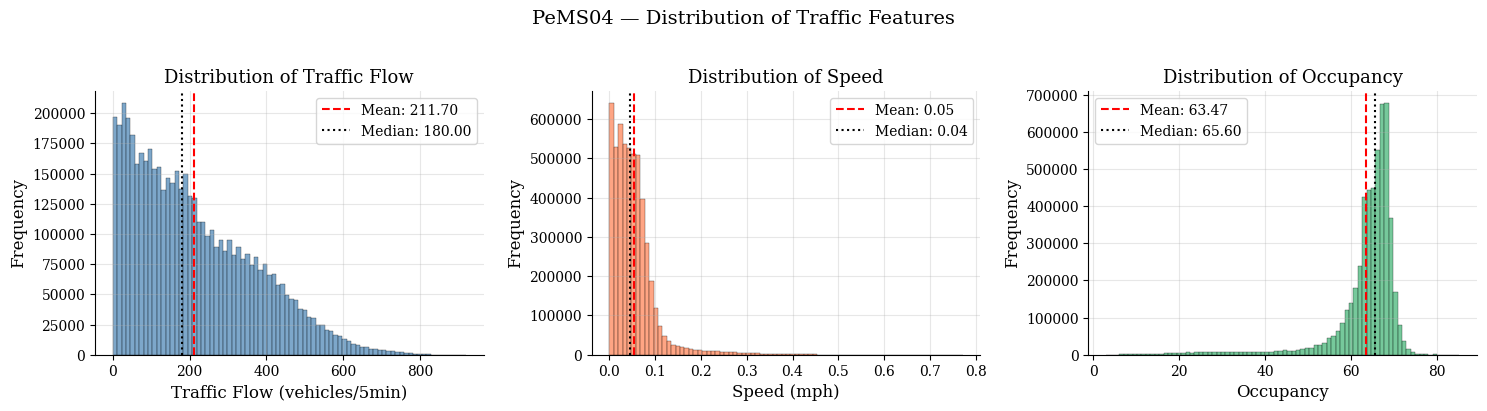

In [8]:
# ============================================================
# HÜCRE 6 — Flow, Speed, Occupancy dağılımları
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = [
    (flow.flatten(),      'Traffic Flow (vehicles/5min)', 'steelblue'),
    (speed.flatten(),     'Speed (mph)',                  'coral'),
    (occupancy.flatten(), 'Occupancy',                    'mediumseagreen')
]

for ax, (data, title, color) in zip(axes, features):
    ax.hist(data, bins=80, color=color, edgecolor='black', alpha=0.7, linewidth=0.3)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(np.median(data), color='black', linestyle=':', linewidth=1.5, label=f'Median: {np.median(data):.2f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title.split("(")[0].strip()}')
    ax.legend()

plt.suptitle('PeMS04 — Distribution of Traffic Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

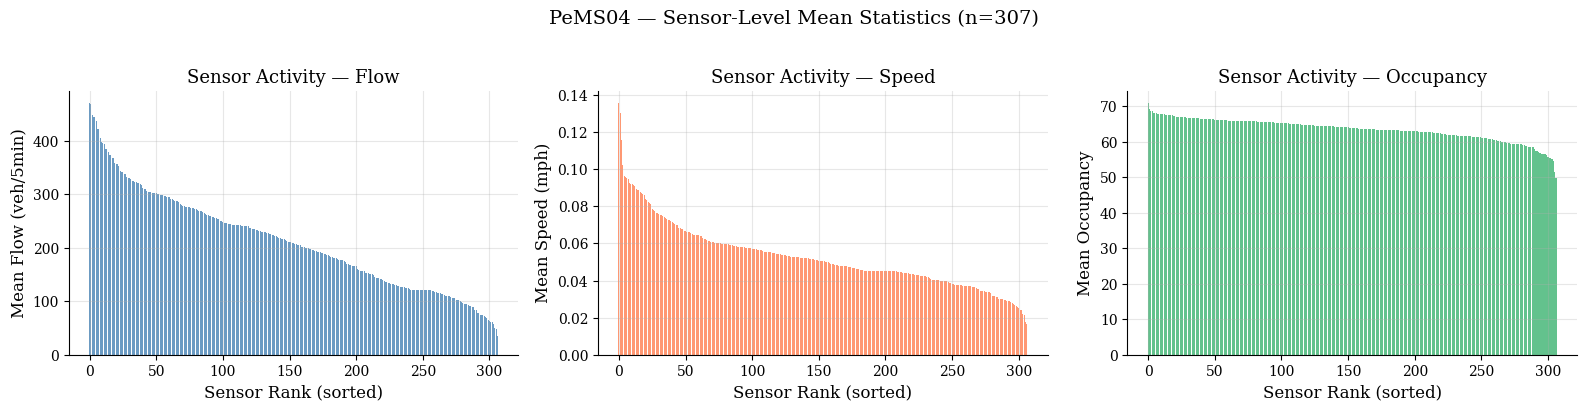


En yoğun 5 sensör (flow): [ 97  41 108 101 111]
En sakin 5 sensör (flow): [266 128  60 132 130]

Flow heterojenliği: en yoğun/en sakin = 13.2x


In [9]:
# ============================================================
# HÜCRE 7 — Sensör bazlı ortalama trafik akışı
# ============================================================
sensor_mean_flow  = flow.mean(axis=0)        # her sensörün ortalama flow'u
sensor_mean_speed = speed.mean(axis=0)
sensor_mean_occ   = occupancy.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(range(307), np.sort(sensor_mean_flow)[::-1], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Sensor Rank (sorted)')
axes[0].set_ylabel('Mean Flow (veh/5min)')
axes[0].set_title('Sensor Activity — Flow')

axes[1].bar(range(307), np.sort(sensor_mean_speed)[::-1], color='coral', alpha=0.8)
axes[1].set_xlabel('Sensor Rank (sorted)')
axes[1].set_ylabel('Mean Speed (mph)')
axes[1].set_title('Sensor Activity — Speed')

axes[2].bar(range(307), np.sort(sensor_mean_occ)[::-1], color='mediumseagreen', alpha=0.8)
axes[2].set_xlabel('Sensor Rank (sorted)')
axes[2].set_ylabel('Mean Occupancy')
axes[2].set_title('Sensor Activity — Occupancy')

plt.suptitle('PeMS04 — Sensor-Level Mean Statistics (n=307)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
# En yoğun ve en sakin 5 sensörü yazdır
print("\nEn yoğun 5 sensör (flow):", np.argsort(sensor_mean_flow)[-5:][::-1])
print("En sakin 5 sensör (flow):", np.argsort(sensor_mean_flow)[:5])
print(f"\nFlow heterojenliği: en yoğun/en sakin = {sensor_mean_flow.max()/sensor_mean_flow[sensor_mean_flow>0].min():.1f}x")

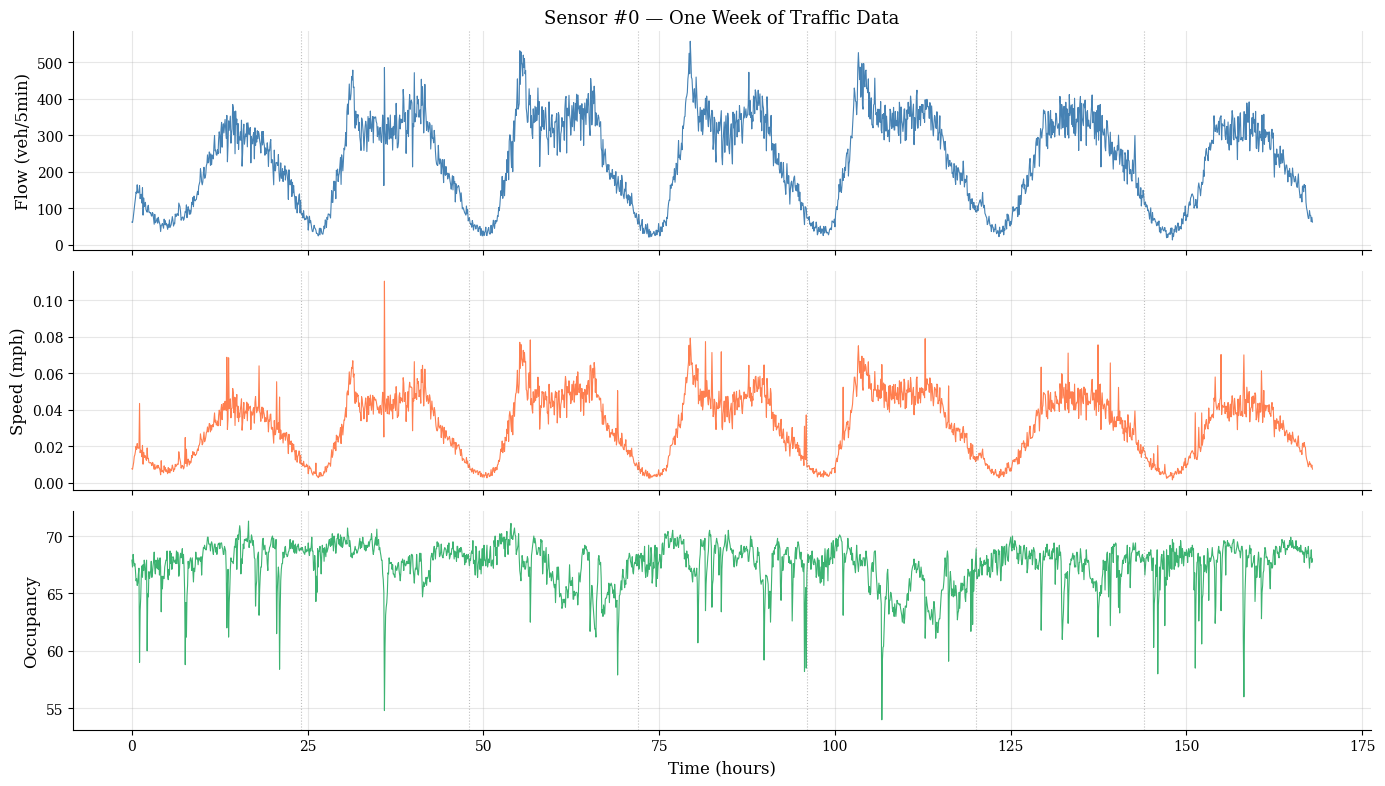

In [10]:
# ============================================================
# HÜCRE 8 — Örnek sensörün haftalık trafik paterni
# ============================================================
sample_sensor = 0  # ilk sensör, sonra değiştirebilirsin
samples_per_day = 288  # 24*60/5
days_to_show = 7

end_idx = samples_per_day * days_to_show
time_hours = np.arange(end_idx) * 5 / 60  # saatlere çevir

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(time_hours, flow[:end_idx, sample_sensor],      color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Flow (veh/5min)')
axes[0].set_title(f'Sensor #{sample_sensor} — One Week of Traffic Data')

axes[1].plot(time_hours, speed[:end_idx, sample_sensor],     color='coral', linewidth=0.8)
axes[1].set_ylabel('Speed (mph)')

axes[2].plot(time_hours, occupancy[:end_idx, sample_sensor], color='mediumseagreen', linewidth=0.8)
axes[2].set_ylabel('Occupancy')
axes[2].set_xlabel('Time (hours)')

# Gün ayraçları
for ax in axes:
    for d in range(1, days_to_show):
        ax.axvline(d*24, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

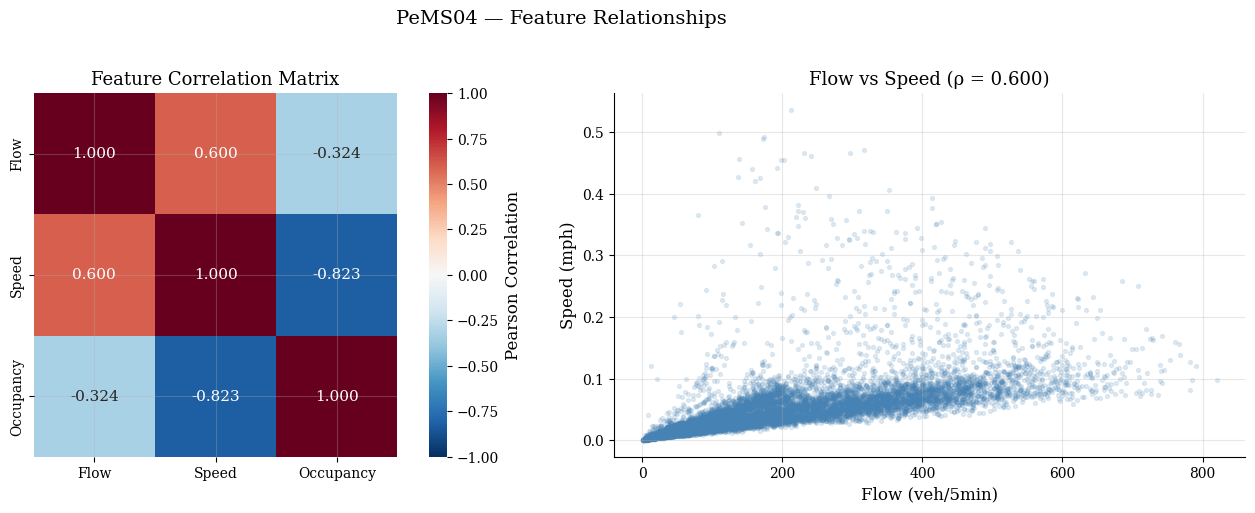


Korelasyon matrisi:
            Flow  Speed  Occupancy
Flow       1.000  0.600     -0.324
Speed      0.600  1.000     -0.823
Occupancy -0.324 -0.823      1.000


In [11]:
# ============================================================
# HÜCRE 9 — Flow, Speed, Occupancy arasındaki korelasyon
# ============================================================
# Tüm sensör ve zamanları düzleştir
all_flow = flow.flatten()
all_speed = speed.flatten()
all_occ = occupancy.flatten()

# Sıfır olmayan örnekleri al (sensör arızalarını ayıkla)
mask = (all_flow > 0) & (all_speed > 0)
sample_idx = np.random.RandomState(42).choice(mask.sum(), size=10000, replace=False)

corr_df = pd.DataFrame({
    'Flow':       all_flow[mask][sample_idx],
    'Speed':      all_speed[mask][sample_idx],
    'Occupancy':  all_occ[mask][sample_idx]
})

# Korelasyon matrisi
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[0],
            cbar_kws={'label': 'Pearson Correlation'})
axes[0].set_title('Feature Correlation Matrix')

# Scatter: Flow vs Speed (en kritik ilişki)
axes[1].scatter(corr_df['Flow'], corr_df['Speed'], alpha=0.15, s=8, color='steelblue')
axes[1].set_xlabel('Flow (veh/5min)')
axes[1].set_ylabel('Speed (mph)')
axes[1].set_title(f'Flow vs Speed (ρ = {corr_matrix.loc["Flow","Speed"]:.3f})')

plt.suptitle('PeMS04 — Feature Relationships', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

print("\nKorelasyon matrisi:")
print(corr_matrix.round(3))

Z-skoru |z|>3 ile anomali oranı (% — sensör bazlı):
         Flow   Speed  Occupancy
count  307.00  307.00     307.00
mean     0.04    1.40       2.17
std      0.16    1.30       1.39
min      0.00    0.00       0.00
25%      0.00    0.28       1.27
50%      0.00    1.01       1.77
75%      0.01    2.44       2.98
max      1.98    6.54       7.36


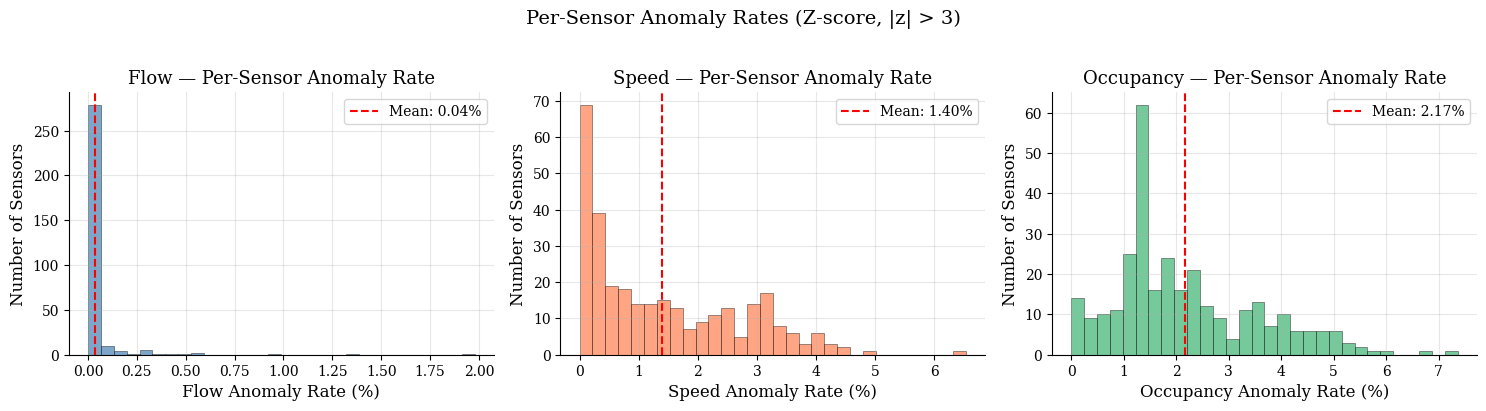

In [12]:
# ============================================================
# HÜCRE 10 — Sensör bazlı Z-skoru ve anomali oranı analizi
# ============================================================
def compute_zscore_anomaly_rate(data_2d, threshold=3):
    """
    Her sensör için ayrı z-skor hesapla, |z| > threshold olanları say.
    data_2d: shape (time, sensors)
    """
    means = data_2d.mean(axis=0, keepdims=True)
    stds  = data_2d.std(axis=0, keepdims=True)
    stds  = np.where(stds == 0, 1, stds)  # sıfır bölmeyi engelle
    z = (data_2d - means) / stds
    anomaly_mask = np.abs(z) > threshold
    return z, anomaly_mask

z_flow, anom_flow   = compute_zscore_anomaly_rate(flow)
z_speed, anom_speed = compute_zscore_anomaly_rate(speed)
z_occ, anom_occ     = compute_zscore_anomaly_rate(occupancy)

# Sensör bazlı anomali oranları
rates_per_sensor = pd.DataFrame({
    'Flow':       anom_flow.mean(axis=0)  * 100,
    'Speed':      anom_speed.mean(axis=0) * 100,
    'Occupancy':  anom_occ.mean(axis=0)   * 100
})

print("Z-skoru |z|>3 ile anomali oranı (% — sensör bazlı):")
print(rates_per_sensor.describe().round(2))

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['Flow', 'Speed', 'Occupancy'], ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(rates_per_sensor[col], bins=30, color=color, edgecolor='black', alpha=0.7, linewidth=0.4)
    ax.axvline(rates_per_sensor[col].mean(), color='red', linestyle='--',
               label=f'Mean: {rates_per_sensor[col].mean():.2f}%')
    ax.set_xlabel(f'{col} Anomaly Rate (%)')
    ax.set_ylabel('Number of Sensors')
    ax.set_title(f'{col} — Per-Sensor Anomaly Rate')
    ax.legend()

plt.suptitle('Per-Sensor Anomaly Rates (Z-score, |z| > 3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

Seçilen 4 sensör (farklı yoğunluk profilleri):
Sensor #278 (P25) | Flow=128.48 | Speed= 0.03 | Occ=66.1035
Sensor #240 (P50) | Flow=207.13 | Speed= 0.07 | Occ=58.6972
Sensor # 71 (P75) | Flow=274.65 | Speed= 0.04 | Occ=64.7223
Sensor #298 (P95) | Flow=372.35 | Speed= 0.07 | Occ=60.0025


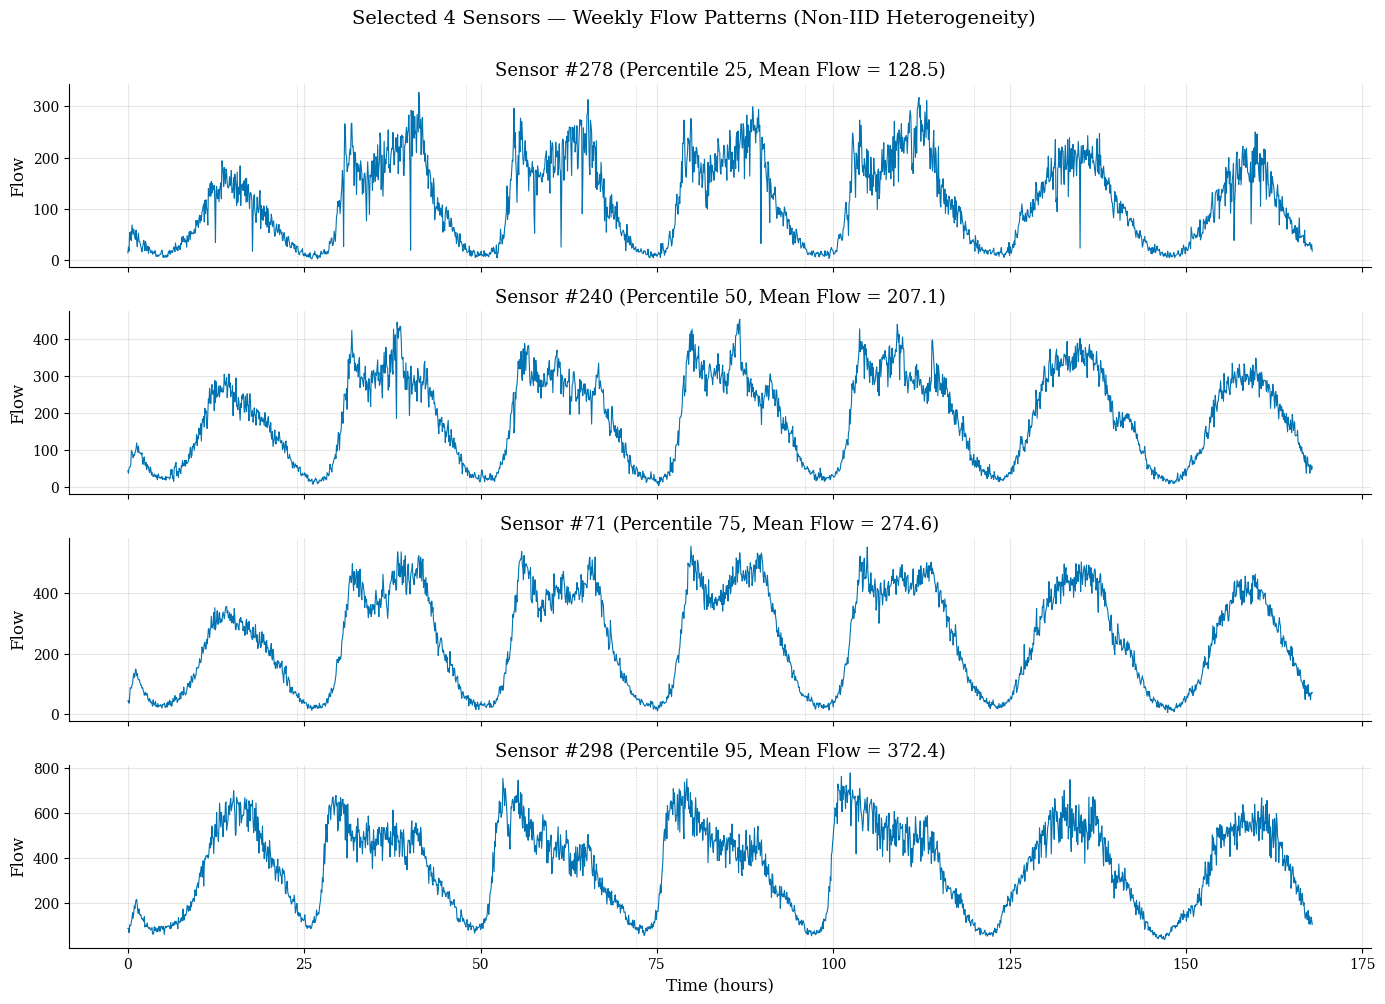

In [13]:
# ============================================================
# HÜCRE 11 — 4 sensörün stratejik seçimi (Non-IID için heterojen)
# ============================================================
# Sensörleri ortalama flow'a göre 4 katmana böl: 25%, 50%, 75%, 95%
percentiles = [25, 50, 75, 95]
sensor_flow_sorted = np.argsort(sensor_mean_flow)

selected_sensors = []
for p in percentiles:
    idx = sensor_flow_sorted[int(307 * p / 100) - 1]
    selected_sensors.append(int(idx))

print("Seçilen 4 sensör (farklı yoğunluk profilleri):")
print("="*70)
for i, s in enumerate(selected_sensors):
    print(f"Sensor #{s:3d} (P{percentiles[i]:>2}) | "
          f"Flow={sensor_mean_flow[s]:6.2f} | "
          f"Speed={sensor_mean_speed[s]:5.2f} | "
          f"Occ={sensor_mean_occ[s]:.4f}")

# Bu 4 sensörün haftalık paternlerini karşılaştır
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
end_idx = samples_per_day * 7
time_hours = np.arange(end_idx) * 5 / 60

for ax, s, p in zip(axes, selected_sensors, percentiles):
    ax.plot(time_hours, flow[:end_idx, s], linewidth=0.8)
    ax.set_ylabel('Flow')
    ax.set_title(f'Sensor #{s} (Percentile {p}, Mean Flow = {sensor_mean_flow[s]:.1f})')
    for d in range(1, 7):
        ax.axvline(d*24, color='gray', linestyle=':', alpha=0.4, linewidth=0.7)

axes[-1].set_xlabel('Time (hours)')
plt.suptitle('Selected 4 Sensors — Weekly Flow Patterns (Non-IID Heterogeneity)',
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig01_feature_distributions.png', bbox_inches='tight', dpi=300)
plt.show()

In [14]:
# ============================================================
# HÜCRE 12 — Seçilen sensörlerin anomali profilini özetle
# ============================================================
summary = []
for s, p in zip(selected_sensors, percentiles):
    summary.append({
        'Sensor ID':            s,
        'Percentile':           f'P{p}',
        'Mean Flow':            round(sensor_mean_flow[s], 2),
        'Mean Speed':           round(sensor_mean_speed[s], 2),
        'Mean Occupancy':       round(sensor_mean_occ[s], 4),
        'Anomaly % (Flow)':     round(anom_flow[:, s].mean()*100, 2),
        'Anomaly % (Speed)':    round(anom_speed[:, s].mean()*100, 2),
        'Anomaly % (Occ)':      round(anom_occ[:, s].mean()*100, 2),
    })

summary_df = pd.DataFrame(summary)
print("Seçilen Sensörlerin Özet Tablosu (Bildiriye Eklenecek):")
print("="*100)
print(summary_df.to_string(index=False))

# CSV olarak kaydet
summary_df.to_csv(f'{RESULTS_DIR}/selected_sensors_summary.csv', index=False)
print("\n✓ Özet '../results/selected_sensors_summary.csv' olarak kaydedildi.")

Seçilen Sensörlerin Özet Tablosu (Bildiriye Eklenecek):
 Sensor ID Percentile  Mean Flow  Mean Speed  Mean Occupancy  Anomaly % (Flow)  Anomaly % (Speed)  Anomaly % (Occ)
       278        P25     128.48        0.03         66.1035               0.0               0.12             1.17
       240        P50     207.13        0.07         58.6972               0.0               1.50             0.39
        71        P75     274.65        0.04         64.7223               0.0               0.01             1.37
       298        P95     372.35        0.07         60.0025               0.0               1.53             1.24

✓ Özet '../results/selected_sensors_summary.csv' olarak kaydedildi.


In [15]:
# ============================================================
# HÜCRE 13 — 4 sensörün verisini ayrı CSV'ler olarak kaydet
# ============================================================
import os
os.makedirs('../data/processed', exist_ok=True)

for s in selected_sensors:
    df = pd.DataFrame({
        'time_step':  np.arange(X.shape[0]),
        'flow':       flow[:, s],
        'speed':      speed[:, s],
        'occupancy':  occupancy[:, s]
    })
    path = f'{DATA_DIR}/sensor_{s:03d}.csv'
    df.to_csv(path, index=False)
    print(f'✓ {path}  | shape={df.shape}')

print("\n4 sensörün CSV dosyaları hazır.")

✓ data/processed/sensor_278.csv  | shape=(16992, 4)
✓ data/processed/sensor_240.csv  | shape=(16992, 4)
✓ data/processed/sensor_071.csv  | shape=(16992, 4)
✓ data/processed/sensor_298.csv  | shape=(16992, 4)

4 sensörün CSV dosyaları hazır.


In [16]:
# ============================================================
# HÜCRE 14 — Notebook'u GitHub'a kaydet
# ============================================================
print("="*60)
print("ŞIMDI YAPILACAKLAR:")
print("="*60)
print("""
1. File → Save a copy in GitHub
   File path: notebooks/01_pems04_exploration.ipynb

2. CSV ve görsellerin GitHub'a gitmesi için manuel commit:
""")
!cd .. && git add data/processed/ results/ && \
        git -c user.email="enesavci@example.com" \
            -c user.name="Enes Avci" \
            commit -m "Add PeMS04 exploration outputs: 4 sensors + figures" && \
        git push

ŞIMDI YAPILACAKLAR:

1. File → Save a copy in GitHub
   File path: notebooks/01_pems04_exploration.ipynb

2. CSV ve görsellerin GitHub'a gitmesi için manuel commit:

fatal: not a git repository (or any of the parent directories): .git
